In [27]:
# general 
import scipy as sp
import pickle
from tqdm.notebook import tqdm
import json
import getdist
from getdist import plots, MCSamples
import matplotlib.pyplot as plt

# density estimation 
from sbi.inference import NPE, NLE
import torch
from sbi.analysis import pairplot
from sbi.analysis import plot_summary
from sbi.utils import BoxUniform
from sbi.diagnostics import run_sbc
from sbi.analysis.plot import sbc_rank_plot

In [2]:
import multiprocessing
num_cores = multiprocessing.cpu_count()
print(f'Number of CPU cores available: {num_cores}')

if torch.cuda.is_available():
    device = 'cuda'
    print(f'Device: {torch.cuda.get_device_name(0)}')
elif torch.backends.mps.is_available():
    device = 'mps'
    print(f'Device: MPS')    
else:
    device = 'cpu'
    print('Device: CPU')

Number of CPU cores available: 14
Device: MPS


The dimension of the parameter datset is (7999, 6)
The dimension of the compressed data dataset is (7999, 6)


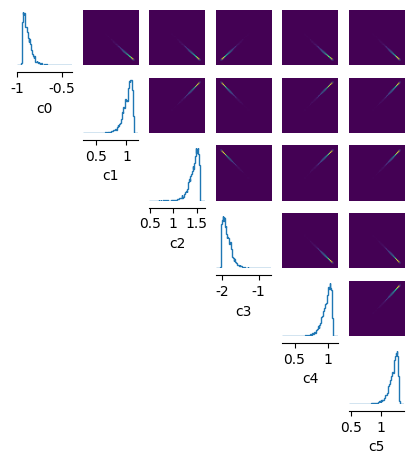

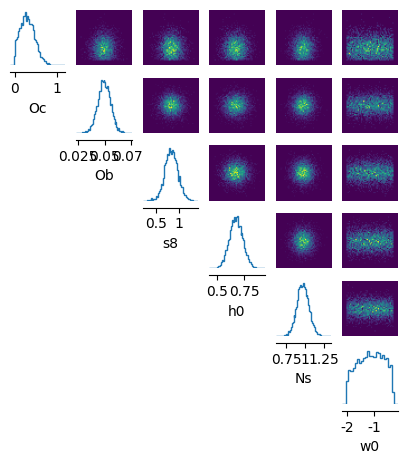

In [4]:
with open('compressed_data/VMIM_5transforms_8bins_min-4.0_max4.0.pkl', 'rb') as f:
    load = pickle.load(f)
    gt = load["ground_truth"]
    cd = load["compressed_data"]
    print('The dimension of the parameter datset is', gt.shape)
    print('The dimension of the compressed data dataset is', cd.shape)

param_names = ['Oc','Ob','s8','h0','Ns','w0']
_ = pairplot(cd, figsize=(5,5), labels=['c0','c1','c2','c3','c4','c5'])
_ = pairplot(gt, figsize=(5,5), labels=param_names)
# print(cls_samples)
# print(np.cov(cls_samples))
# print(np.cov(param_samples))
        

In [ ]:
nle = NLE(density_estimator="nsf", device='mps')

# Convert parameter and cls data to tensors for training
gt = torch.tensor(gt, dtype=torch.float32)
cd = torch.tensor(cd, dtype=torch.float32)
# Check whether the trainig data is of correct shape and network has been instantiated
print('parameter samples', type(gt), gt.shape, 'cls samples', type(cd), cd.shape)
print('Density estimation model:', nle)

nle = nle.append_simulations(gt, cd, data_device='mps')
nle.train()

_ = plot_summary(nle)
with open("trained_models/NLE_VMIM_sbi_lens.pkl", "wb") as f:
    pickle.dump(nle, f)

parameter samples <class 'torch.Tensor'> torch.Size([7999, 6]) cls samples <class 'torch.Tensor'> torch.Size([7999, 6])
Density estimation model: <sbi.inference.trainers.nle.nle_a.NLE_A object at 0x126f2fa10>


/Users/brian/Library/CloudStorage/OneDrive-Personal/Documents/UCL/Projects/sbi-compression/.venv/lib/python3.13/site-packages/sbi/inference/trainers/base.py:303: UserWarning: Data x has device 'cpu'. Moving x to the data_device 'mps'. Training will proceed on device 'mps'.
  theta, x = validate_theta_and_x(
/Users/brian/Library/CloudStorage/OneDrive-Personal/Documents/UCL/Projects/sbi-compression/.venv/lib/python3.13/site-packages/sbi/inference/trainers/base.py:303: UserWarning: Parameters theta has device 'cpu'. Moving theta to the data_device 'mps'. Training will proceed on device 'mps'.
  theta, x = validate_theta_and_x(


 Neural network successfully converged after 112 epochs.

NFlowsFlow(
  (net): Flow(
    (_transform): CompositeTransform(
      (_transforms): ModuleList(
        (0): PointwiseAffineTransform()
        (1): PiecewiseRationalQuadraticCouplingTransform(
          (transform_net): ResidualNet(
            (initial_layer): Linear(in_features=9, out_features=50, bias=True)
            (blocks): ModuleList(
              (0-1): 2 x ResidualBlock(
                (context_layer): Linear(in_features=6, out_features=50, bias=True)
                (linear_layers): ModuleList(
                  (0-1): 2 x Linear(in_features=50, out_features=50, bias=True)
                )
                (dropout): Dropout(p=0.0, inplace=False)
              )
            )
            (final_layer): Linear(in_features=50, out_features=87, bias=True)
          )
        )
        (2): LULinear()
        (3): PiecewiseRationalQuadraticCouplingTransform(
          (transform_net): ResidualNet(
            (initial_layer): Linear(in_features=9, out_features=50, bias=Tru

In [ ]:
from torch import Tensor
from torch.distributions import Normal, Distribution
from sbi.utils import MultipleIndependent

class TruncatedNormal(Distribution):
    def __init__(
            self,
            mu: Tensor,
            sigma: Tensor,
            lower: Tensor = None,
            upper: Tensor = None,
        ):
        self.mu = mu
        self.sigma = sigma
        if lower == None:
            self.lower = torch.tensor(float('-inf'), device=mu.device)
        else: 
            self.lower = lower
        if upper == None:
            self.upper = torch.tensor(float('inf'), device=mu.device)
        else: 
            self.upper = upper
        super().__init__(batch_shape=torch.Size([]), event_shape=mu.shape)
        self.dist = Normal(mu, sigma)
        self.log_Z = torch.log(self.dist.cdf(self.upper) - self.dist.cdf(self.lower)) # Truncation normalisation

    def sample(self, sample_shape=torch.Size([])):
        # Reject samples if outside of trauncation bounds
        num_samples = torch.Size(sample_shape).numel() if sample_shape else 1
        samples = []
        while len(samples) < num_samples:
            s = self.dist.sample((num_samples,))
            mask = (s>=self.lower) & (s<=self.upper)
            # If it's multi-dimensional data, like a 2D coordinate [x, y], ensuree that both x and y are inside the bounds. If even one coordinate is out of bounds, the whole point is rejected
            valid = s[mask.all(dim=-1)] if s.dim()>1 else s[mask] 
            samples.extend(valid)
        final_samples = torch.stack(samples[:num_samples]).reshape(sample_shape + self.mu.shape)
        return final_samples
    
    def log_prob(self, values):
        lp = self.dist.log_prob(values)
        lp = lp - self.log_Z
        out_of_bounds = (values < self.lower) | (values > self.upper)
        if values.dim() > 1:
            # For multivariate, it's out of bounds if ANY dimension is out
            out_of_bounds = out_of_bounds.any(dim=-1, keepdim=True)
        lp = torch.where(out_of_bounds, torch.tensor(float('-inf'), device=lp.device), lp)
        return lp

with open("trained_models/NLE_VMIM_sbi_lens.pkl", "rb") as f:
    estimator = pickle.load(f)

prior = MultipleIndependent([
    TruncatedNormal(torch.tensor([0.2664]).to(device), 
                    torch.tensor([0.2]).to(device), 
                    lower=torch.tensor([0.0]).to(device)
                    ),
    Normal(torch.tensor([0.0492]).to(device), 
           torch.tensor([0.006]).to(device)
           ),
    Normal(torch.tensor([0.831]).to(device), 
           torch.tensor([0.14]).to(device)
           ),
    Normal(torch.tensor([0.6727]).to(device), 
           torch.tensor([0.063]).to(device)
           ),
    Normal(torch.tensor([0.9645]).to(device), 
           torch.tensor([0.08]).to(device)
           ),
    TruncatedNormal(torch.tensor([-1.0]).to(device), 
                    torch.tensor([0.9]).to(device), 
                    lower=torch.tensor([-2.0]).to(device), 
                    upper=torch.tensor([-0.3]).to(device)
                    ),
    ],
    device=device)

posterior = nle.build_posterior(prior=prior)
print(posterior)
cd_obs = torch.tensor(cd[42,:], dtype=torch.float32)
print('The compressed observation is', cd_obs)
n_samples = 1000
samples = posterior.sample((n_samples,), x=cd_obs)
with open(f"posterior_samples/NLE_VMIM_posterior_{n_samples}samples.pkl", "wb") as f:
    pickle.dump(samples, f)


/Users/brian/Library/CloudStorage/OneDrive-Personal/Documents/UCL/Projects/sbi-compression/.venv/lib/python3.13/site-packages/sbi/inference/potentials/likelihood_based_potential.py:52: UserWarning: The passed prior has no support property, transform will be constructed from mean and std. If the passed prior is supposed to be bounded consider implementing the prior.support property.
  theta_transform = mcmc_transform(
/Users/brian/Library/CloudStorage/OneDrive-Personal/Documents/UCL/Projects/sbi-compression/.venv/lib/python3.13/site-packages/sbi/utils/sbiutils.py:879: UserWarning: The passed discrete prior has no mean or stddev attribute, estimating them from samples to build affine standardizing transform.
  transform = prior_mean_std_transform(prior, device)
/var/folders/yt/ybnb7bw10vj2y7213d6y2l_00000gn/T/ipykernel_32456/3685491865.py:80: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad

Posterior p(θ|x) of type MCMCPosterior. It provides MCMC to .sample() from the posterior and can evaluate the _unnormalized_ posterior density with .log_prob().
The compressed observation is tensor([-0.8679,  0.9889,  1.4074, -1.8443,  0.9620,  1.1812])


Running vectorized MCMC with 20 chains: 100%|██████████| 6000/6000 [05:54<00:00, 16.94it/s]


tensor([ 0.2513,  0.0468,  0.9253,  0.7494,  1.0298, -1.6602])


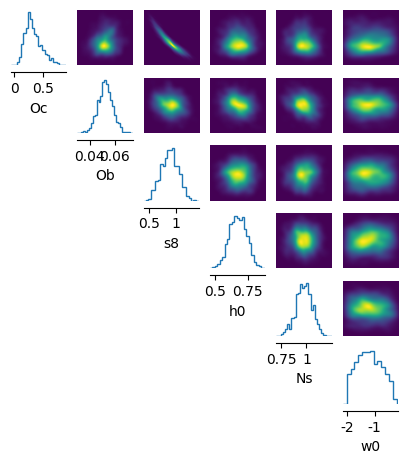

In [ ]:
gt_obs = gt[42,:]
print(gt_obs)
_ = pairplot(samples.cpu().numpy(), upper='kde', figsize=(5,5), labels=param_names)

Removed no burn in
[[0.3685944080352783, 0.04833216220140457, 0.8691107034683228, 0.6894925236701965, 0.9698247313499451, -0.6380051970481873], [0.29768526554107666, 0.04838547483086586, 0.8705950975418091, 0.6993433237075806, 0.9151101112365723, -1.4939252138137817], [0.2971150875091553, 0.05760086327791214, 0.8817468285560608, 0.6549105048179626, 1.0824142694473267, -1.3880847692489624], [0.3268105387687683, 0.05564667657017708, 0.819807231426239, 0.6374253630638123, 0.9024088978767395, -1.6690771579742432], [0.2980436086654663, 0.07029525190591812, 0.854777991771698, 0.7302116751670837, 0.8672020435333252, -1.7905243635177612], [0.30732595920562744, 0.04830469191074371, 0.8017370104789734, 0.799909234046936, 0.8944248557090759, -1.6361327171325684], [0.36693429946899414, 0.045863114297389984, 0.7914241552352905, 0.7093298435211182, 1.0950478315353394, -1.302423357963562], [0.3208976686000824, 0.046512849628925323, 0.7876632809638977, 0.6716587543487549, 0.9852067232131958, -1.135482

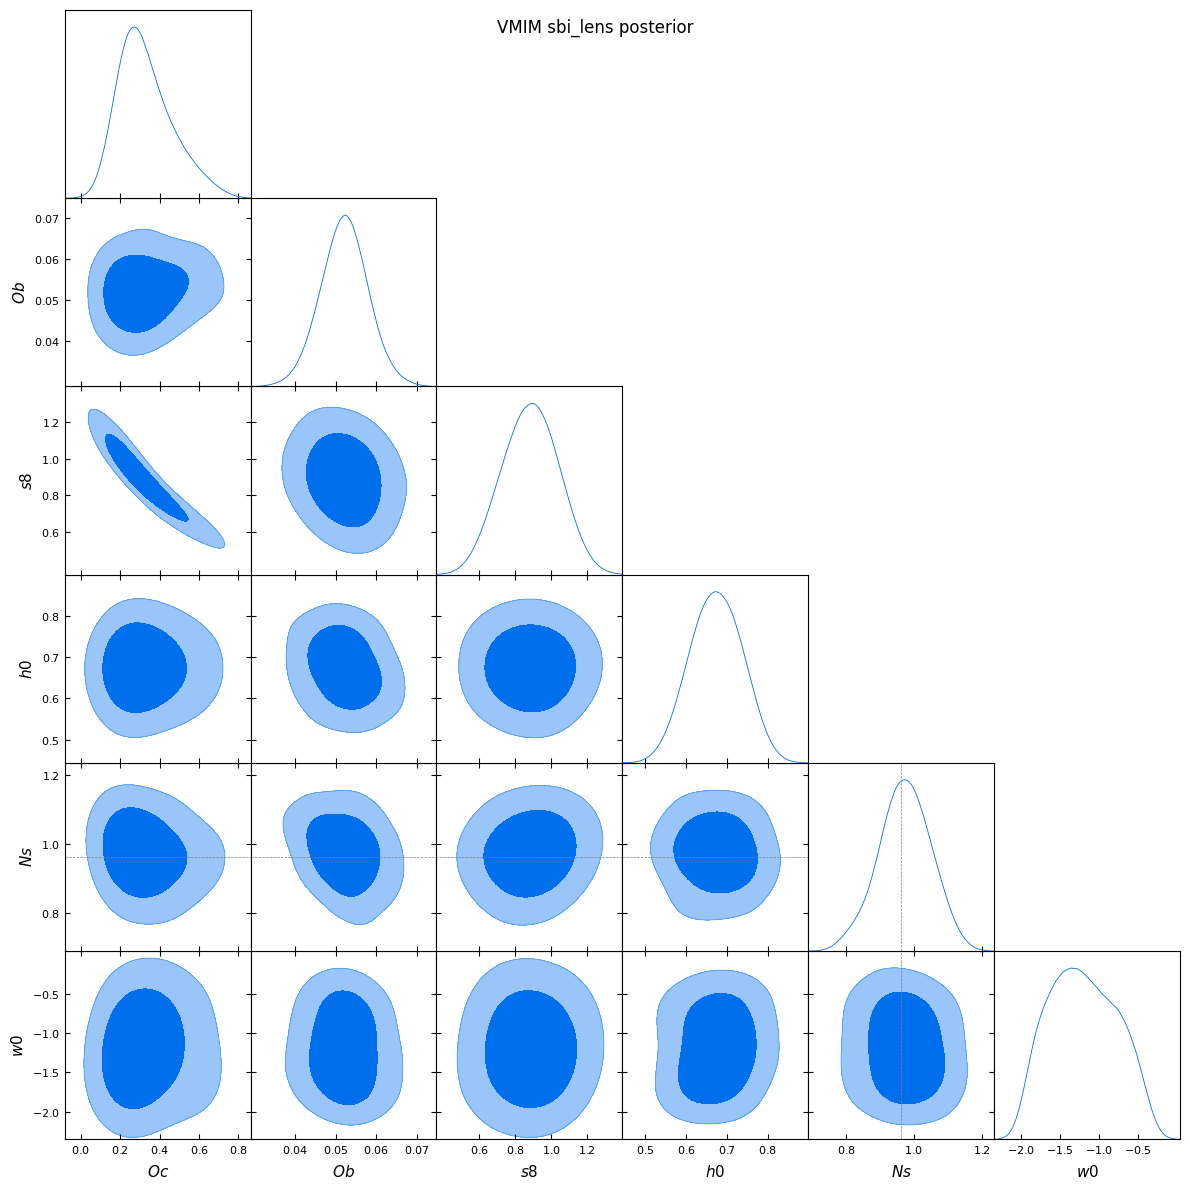

In [31]:
g = plots.get_subplot_plotter()
# convert to numpy array (nsamples, nparams)
samples_np = samples.cpu().numpy()
# create a getdist MCSamples object with names/labels
mcs = MCSamples(samples=samples_np, names=param_names, labels=param_names)
print(samples_np.tolist())
# pass the MCSamples (not a nested list of lists)
g.triangle_plot([mcs], filled=True)
g.add_param_markers(
        {param_names[0]: cd_obs[0].item(), 
        param_names[1]: cd_obs[1].item(), 
        param_names[2]: cd_obs[2].item(), 
        param_names[3]: cd_obs[3].item(), 
        param_names[4]: cd_obs[4].item(), 
        param_names[5]: cd_obs[5].item(), 
        }
    )
plt.suptitle("VMIM sbi_lens posterior")
plt.savefig("plots/posteriors/VMIM_posterior.pdf")
plt.show()
